In [1]:
import warnings
warnings.filterwarnings("ignore")

!pip install -q ultralytics

from ultralytics import YOLO

model = YOLO("/kaggle/input/models/ahsanneural/head-detector-yolo26n-pt/pytorch/default/1/head_detector_yolo26n.pt")

print(model)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(i

In [2]:
!wget -q --show-progress -O rpee_heads.zip "http://ped.fz-juelich.de/data/machine_learning/2024_11_Recognition_In_Field_Studies/data/2024rpee_heads_dataset.zip"

!unzip -q rpee_heads.zip -d rpee_heads

rpee_heads.zip      100%[===================>]   1.08G  29.5MB/s    in 38s     


In [3]:
import os

for root, dirs, files in os.walk("rpee_heads"):
    for f in files[:3]:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, f))

rpee_heads/testing/test/images/EXP_250_q_45_h0_frames_EXP_250_q_45_h0_frames_frame_600.jpg
rpee_heads/testing/test/images/DMAGB72_GX140011_frame_7875.jpg
rpee_heads/testing/test/images/DMAGB41_GX200008_frame_9750.jpg
rpee_heads/training/train/images/DMPG41_GP234092_frame_12750.jpg
rpee_heads/training/train/images/DMPG41_GP214092_frame_1500.jpg
rpee_heads/training/train/images/3C080_entry1_bend90_wI_nM_corrected_trimmed_1_frames_3C080_entry1_bend90_wI_nM_corrected_trimmed_1_frames_frame_10000.jpg
rpee_heads/validation/val/images/DMPG41_GP204092_frame_7750.jpg
rpee_heads/validation/val/images/EXP_120_c_12_h-_frames_EXP_120_c_12_h-_frames_frame_475.jpg
rpee_heads/validation/val/images/entrance_1_mitAnsage_ueberkopf_frames_entrance_1_mitAnsage_ueberkopf_frames_frame_3250.jpg


In [4]:
results = model.predict(
    source="rpee_heads/testing/test/images/DMLGB72_GX020017_frame_9000.jpg",
    conf=0.3,
    verbose=False
)
print(f"Heads detected: {len(results[0].boxes)}")

Heads detected: 99


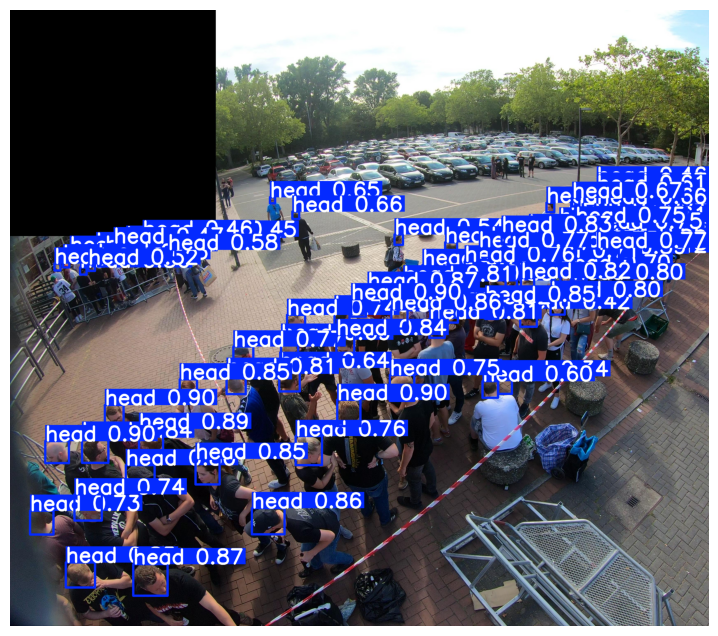

In [5]:
import matplotlib.pyplot as plt

annotated = results[0].plot()
plt.figure(figsize=(10, 8))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.show()

In [6]:
import cv2
import numpy as np

def compute_homography(image_points, real_world_points):
    image_points = np.array(image_points, dtype=np.float32)
    real_world_points = np.array(real_world_points, dtype=np.float32)
    H, status = cv2.findHomography(image_points, real_world_points)
    return H

def pixel_to_ground(H, pixel_point):
    px, py = pixel_point
    point = np.array([px, py, 1.0], dtype=np.float32)
    mapped = H @ point
    mapped = mapped / mapped[2]
    return mapped[0], mapped[1]

def compute_visible_ground_area(H, image_width, image_height):
    corners = [(0, 0), (image_width, 0), (image_width, image_height), (0, image_height)]
    ground_corners = [pixel_to_ground(H, c) for c in corners]
    xs = [p[0] for p in ground_corners]
    ys = [p[1] for p in ground_corners]
    area = 0.5 * abs(sum(xs[i]*ys[(i+1)%4] - xs[(i+1)%4]*ys[i] for i in range(4)))
    return area

def compute_density(head_count, ground_area_sqm):
    if ground_area_sqm <= 0:
        return 0
    return head_count / ground_area_sqm

In [7]:
image_points = [(0, 400), (720, 400), (720, 646), (0, 646)]
real_world_points = [(0, 0), (10, 0), (10, 15), (0, 15)]

H = compute_homography(image_points, real_world_points)
ground_area = compute_visible_ground_area(H, 720, 646)
density = compute_density(head_count=99, ground_area_sqm=ground_area)

print(f"Estimated visible ground area: {ground_area:.2f} sq meters")
print(f"Estimated density: {density:.2f} heads per sq meter")

Estimated visible ground area: 393.90 sq meters
Estimated density: 0.25 heads per sq meter


In [8]:
from dataclasses import dataclass
from typing import List
import json

@dataclass
class SpotReading:
    spot_id: str
    spot_name: str
    head_count: int
    density: float = None  # optional, filled in once calibration exists
    timestamp: str = None

def rank_spots(readings: List[SpotReading], use_density: bool = False) -> List[dict]:
    def score(r):
        if use_density and r.density is not None:
            return r.density
        return r.head_count

    sorted_readings = sorted(readings, key=score)

    ranked = []
    for i, r in enumerate(sorted_readings, start=1):
        ranked.append({
            "rank": i,
            "spot_id": r.spot_id,
            "spot_name": r.spot_name,
            "head_count": r.head_count,
            "density": r.density,
            "crowd_level": crowd_level_label(score(r), use_density),
        })
    return ranked

def crowd_level_label(value: float, use_density: bool) -> str:
    if use_density:
        if value < 0.5:
            return "Low"
        elif value < 1.5:
            return "Moderate"
        else:
            return "High"
    else:
        if value < 30:
            return "Low"
        elif value < 70:
            return "Moderate"
        else:
            return "High"

def export_ranking_json(ranked: List[dict], filepath: str = "ranking_output.json"):
    with open(filepath, "w") as f:
        json.dump(ranked, f, indent=2)
    return filepath

In [9]:
test_images = {
    "spot_1": "rpee_heads/testing/test/images/DMLGB72_GX020017_frame_9000.jpg",
    "spot_2": "rpee_heads/testing/test/images/3C080_entry1_bend90_wI_nM_corrected_trimmed_1_frames_3C080_entry1_bend90_wI_nM_corrected_trimmed_1_frames_frame_12500.jpg",
    "spot_3": "rpee_heads/testing/test/images/DMPG41_GP244092_frame_9250.jpg",
}

readings = []
for spot_id, path in test_images.items():
    result = model.predict(source=path, conf=0.3, verbose=False)
    count = len(result[0].boxes)
    readings.append(SpotReading(spot_id=spot_id, spot_name=spot_id.replace("_", " ").title(), head_count=count))

ranked = rank_spots(readings)
for r in ranked:
    print(r)

export_ranking_json(ranked)

{'rank': 1, 'spot_id': 'spot_3', 'spot_name': 'Spot 3', 'head_count': 53, 'density': None, 'crowd_level': 'Moderate'}
{'rank': 2, 'spot_id': 'spot_2', 'spot_name': 'Spot 2', 'head_count': 79, 'density': None, 'crowd_level': 'High'}
{'rank': 3, 'spot_id': 'spot_1', 'spot_name': 'Spot 1', 'head_count': 99, 'density': None, 'crowd_level': 'High'}


'ranking_output.json'

In [10]:
def crowd_level_label(value: float, use_density: bool) -> str:
    if use_density:
        if value < 0.5:
            return "Low"
        elif value < 1.5:
            return "Moderate"
        else:
            return "High"
    else:
        if value < 40:
            return "Low"
        elif value < 60:
            return "Moderate"
        elif value < 90:
            return "High"
        else:
            return "Very High"